Summary Statistics:
        Time_spent_Alone   Stage_fear  Social_event_attendance  Going_outside  \
count       2477.000000  2477.000000              2477.000000    2477.000000   
mean           4.522406     0.498991                 3.939039       3.013726   
std            3.491162     0.500100                 2.900044       2.257239   
min            0.000000     0.000000                 0.000000       0.000000   
25%            2.000000     0.000000                 2.000000       1.000000   
50%            4.000000     0.000000                 3.000000       3.000000   
75%            8.000000     1.000000                 6.000000       5.000000   
max           11.000000     1.000000                10.000000       7.000000   

       Drained_after_socializing  Friends_circle_size  Post_frequency  \
count                2477.000000          2477.000000     2477.000000   
mean                    0.498991             6.239806        3.559548   
std                     0.500100       

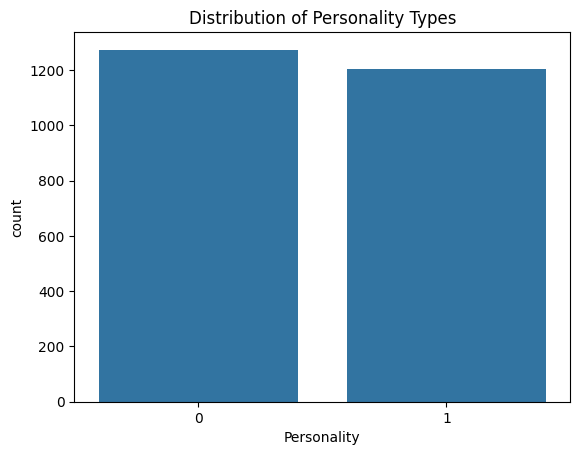

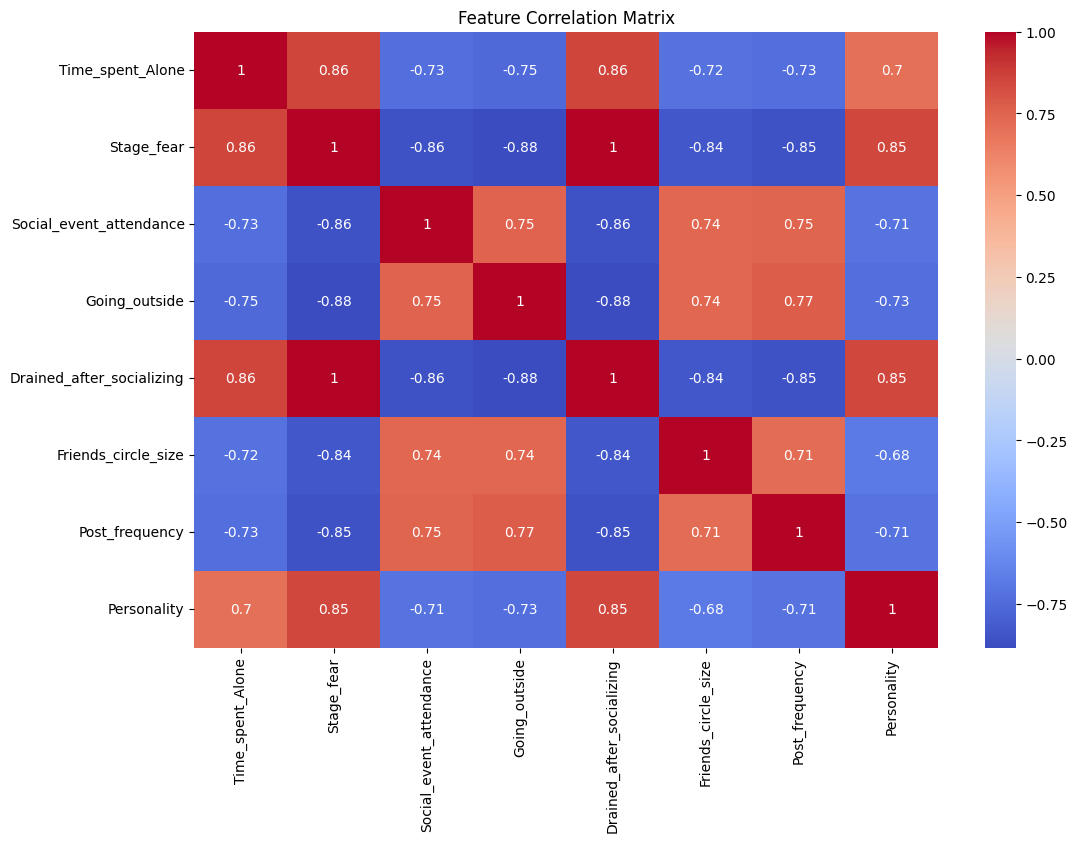


Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.87      0.90       255
           1       0.88      0.93      0.90       255

    accuracy                           0.90       510
   macro avg       0.90      0.90      0.90       510
weighted avg       0.90      0.90      0.90       510


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.87      0.90       255
           1       0.88      0.93      0.90       255

    accuracy                           0.90       510
   macro avg       0.90      0.90      0.90       510
weighted avg       0.90      0.90      0.90       510


kNN Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.87      0.90       255
           1       0.88      0.93      0.90       255

    accuracy                           0.90       510
   macro avg   

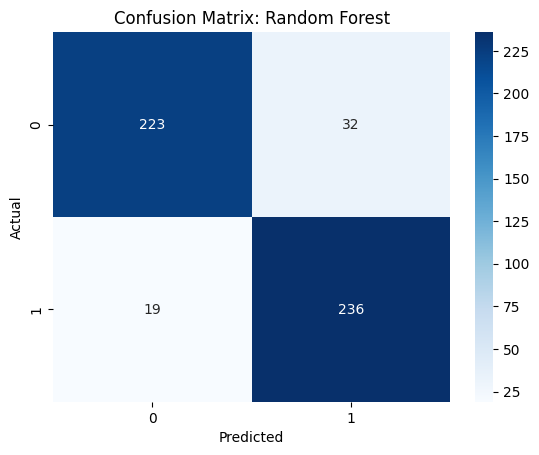

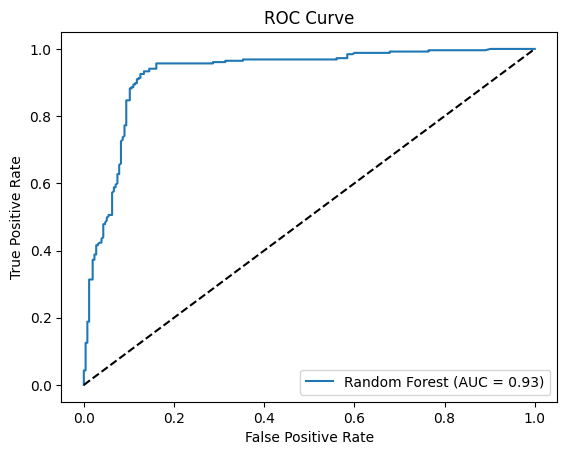

In [7]:
# Enhanced Personality Prediction Script for Final Project

# ================================================
# 1. Import Libraries
# ================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# ================================================
# 2. Load and Clean Data
# ================================================
df = pd.read_csv("personality_dataset.csv")
df.dropna(inplace=True)

# Encode categorical variables
df['Personality'] = LabelEncoder().fit_transform(df['Personality'])
df['Stage_fear'] = LabelEncoder().fit_transform(df['Stage_fear'])
df['Drained_after_socializing'] = LabelEncoder().fit_transform(df['Drained_after_socializing'])

# ================================================
# 3. Exploratory Data Analysis (EDA)
# ================================================
print("Summary Statistics:\n", df.describe())
sns.countplot(x='Personality', data=df)
plt.title('Distribution of Personality Types')
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

# ================================================
# 4. Feature Selection & Transformation
# ================================================
X = df.drop('Personality', axis=1)
y = df['Personality']

pt = PowerTransformer(method='yeo-johnson')
X_transformed = pd.DataFrame(pt.fit_transform(X), columns=X.columns)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_transformed), columns=X.columns)

# Optional: Apply PCA
pca = PCA(n_components=0.95)
X_pca = pd.DataFrame(pca.fit_transform(X_scaled))

# ================================================
# 5. Resample Data (if imbalanced)
# ================================================
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_pca, y)

# ================================================
# 6. Split Data
# ================================================
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# ================================================
# 7. Define Models with GridSearchCV
# ================================================
param_grid = {
    'Logistic Regression': {'C': [0.01, 0.1, 1, 10]},
    'Random Forest': {'n_estimators': [50, 100], 'max_depth': [3, 5, None]},
    'kNN': {'n_neighbors': [3, 5, 7]}
}

models = {
    'Logistic Regression': GridSearchCV(LogisticRegression(), param_grid['Logistic Regression'], cv=5),
    'Random Forest': GridSearchCV(RandomForestClassifier(random_state=42), param_grid['Random Forest'], cv=5),
    'kNN': GridSearchCV(KNeighborsClassifier(), param_grid['kNN'], cv=5),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'GaussianNB': GaussianNB()
}

# ================================================
# 8. Train and Evaluate Models
# ================================================
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    cv_score = cross_val_score(model, X_resampled, y_resampled, cv=5).mean()
    print(f"\n{name} Classification Report:\n", classification_report(y_test, y_pred))
    results.append({'Model': name, 'Accuracy': acc, 'ROC AUC': auc, 'CV Score': cv_score})

results_df = pd.DataFrame(results)
print("\nModel Performance Summary:\n", results_df.sort_values(by='ROC AUC', ascending=False))

# ================================================
# 9. Confusion Matrix for Best Model
# ================================================
best_model_name = results_df.sort_values(by='ROC AUC', ascending=False)['Model'].iloc[0]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

conf_mat = confusion_matrix(y_test, y_pred_best)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ================================================
# 10. ROC Curve for Best Model
# ================================================
y_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# ================================================
# 11. Feature Importance (if applicable)
# ================================================
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.best_estimator_.feature_importances_ if hasattr(best_model, 'best_estimator_') else best_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    sns.barplot(x='Importance', y='Feature', data=importance_df)
    plt.title(f'Feature Importance - {best_model_name}')
    plt.show()
